# Description
```
Problem   : Classification : Multi Input
Type      : Deep learning
Algorithm : Neural network : Functional API
Network   : CNN 
Action    : Relu | Softmax
Loss      : categorical_crossentropy
Train     : Supervised
Input     : Feature | Two labels
Output    : Category | Color
Dataset   : Unstructured : Clothes
```

# General

Import

In [ ]:
import glob, os
import numpy as np
import pandas as pd
import cv2 as cv
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from keras.optimizers.schedules import ExponentialDecay
from keras import optimizers
from keras import models, layers
from keras.models import load_model

Variable

In [ ]:
root_dir = '/Volumes/data/documents/ai_document'
data_dir = '/Volumes/data/develop/ai'

# Dataset

### Data

In [ ]:
bathroom_list = []
bedroom_list = []
frontal_list = []
kitchen_list = []

for i, address in enumerate(glob.glob(f"{data_dir}/dataset/house/dataset/*.*", recursive=True)):
    #---Direction
    path = os.path.dirname(address)
    directory = path.split('/')[-1].split('.')[0]
    name = os.path.splitext(os.path.basename(address))[0]
    extension = os.path.splitext(os.path.basename(address))[1] 
    _, location = name.split("_")
    #---Data
    img = cv.imread(address)
    #---Preprocessingze
    img = cv.resize(img, (32, 32))
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    #---Normalization
    img = img/255.0
    #---Append
    if location == "bathroom" : bathroom_list.append(img)
    elif location == "bedroom" : bedroom_list.append(img)
    elif location == "frontal" : frontal_list.append(img)
    elif location == "kitchen" : kitchen_list.append(img)
    #---Log
    if i>0 and i % 100 == 0 :
        print("[INFO]: {} Processes".format(i))

In [ ]:
bathroom_list = np.array(bathroom_list)
bedroom_list = np.array(bedroom_list)
frontal_list = np.array(frontal_list)
kitchen_list = np.array(kitchen_list)

In [ ]:
print("bathroom: {}".format(len(bathroom_list)))
print("bedroom:  {}".format(len(bedroom_list)))
print("frontal:  {}".format(len(frontal_list)))
print("kitchen:  {}".format(len(kitchen_list)))

### Label

In [ ]:
df = pd.read_csv(
    f"{data_dir}/dataset/house/info.txt", 
    sep=" ",
    names=["col_1", "col_2", "col_3", "col_4", "price"]
)
labels = np.array(df.loc[:, "price"])
labels = labels / np.max(labels)

print("Labels: {}".format(len(labels)))

# Separate tarin and test

In [ ]:
split = train_test_split(
    bathroom_list,
    bedroom_list,
    frontal_list,
    kitchen_list,
    labels,
    test_size=0.2
)
(bathroom_train, bathroom_test, 
 bedroom_train, bedroom_test, 
 frontal_train, frontal_test, 
 kitchen_train, kitchen_test,
 labels_train, labels_test
 ) = split

print(bathroom_train.shape)
print(bathroom_test.shape)
print(bedroom_train.shape)
print(bedroom_test.shape)
print(kitchen_train.shape)
print(kitchen_test.shape)
print(kitchen_train.shape)
print(kitchen_test.shape)
print(labels_train.shape)
print(labels_test.shape)

# Model

### Configuration

Optimizers

In [ ]:
lr_schedule = ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=255,
    decay_rate=0.001,
    staircase=False
)

opt_sgd = optimizers.SGD(learning_rate=lr_schedule)
opt_adam = optimizers.Adam(learning_rate=lr_schedule)

### Layers

bathroom

In [ ]:
bathroom_input = layers.Input(shape=(32, 32, 3))
x = layers.Conv2D(16, (3, 3),activation="relu", padding="same") (bathroom_input)
x = layers.MaxPool2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3),activation="relu", padding="same") (x)
x = layers.MaxPool2D((2, 2))(x)

bedroom

In [ ]:
bedroom_input = layers.Input(shape=(32, 32, 3))
y = layers.Conv2D(16, (3, 3),activation="relu", padding="same") (bedroom_input)
y = layers.MaxPool2D((2, 2))(y)
y = layers.Conv2D(32, (3, 3),activation="relu", padding="same") (y)
y = layers.MaxPool2D((2, 2))(y)

frontal

In [ ]:
frontal_input = layers.Input(shape=(32, 32, 3))
z = layers.Conv2D(16, (3, 3),activation="relu", padding="same") (frontal_input)
z = layers.MaxPool2D((2, 2))(z)
z = layers.Conv2D(32, (3, 3),activation="relu", padding="same") (z)
z = layers.MaxPool2D((2, 2))(z)

kitchen

In [ ]:
kitchen_input = layers.Input(shape=(32, 32, 3))
w = layers.Conv2D(16, (3, 3),activation="relu", padding="same") (kitchen_input)
w = layers.MaxPool2D((2, 2))(w)
w = layers.Conv2D(32, (3, 3),activation="relu", padding="same") (w)
w = layers.MaxPool2D((2, 2))(w)

Concat

In [ ]:
concat_input = layers.concatenate([x, y, z, w], axis=2)
flat_layer = layers.Flatten()(concat_input)
out = layers.Dense(100, activation="relu")(flat_layer)
out = layers.Dense(1, activation="linear")(out)

### Generate

In [ ]:
mdl = models.Model(
    inputs=[bathroom_input, bedroom_input, frontal_input, kitchen_input], 
    outputs = out
)

### Compile

In [ ]:
mdl.compile(
    optimizer=opt_adam, 
    loss="MSE"
)

# Train

In [ ]:
EPOCHS = 40
BATCH_SIZE = 32

H = mdl.fit(
    x = [bathroom_train, bedroom_train, frontal_train, kitchen_train], 
    y = labels_train,
    validation_data=([bathroom_test, bedroom_test, frontal_test, kitchen_test], labels_test),
    epochs=EPOCHS
)

### Save

In [ ]:
mdl.save(f"{data_dir}/model/classification_multi_input.h5")

# Evaluation

Loss

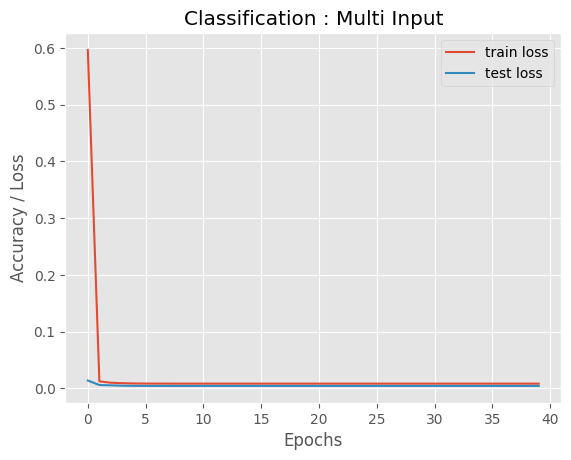

In [ ]:
plt.plot(H.history['loss'], label='train loss')
plt.plot(H.history['val_loss'], label='test loss')

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy / Loss')
plt.title('Classification : Multi Input')
plt.style.use('ggplot')
plt.show()

# Test

In [ ]:
mdl = load_model(f"{data_dir}/model/classification_multi_input.h5")
for address in glob.glob(f"{data_dir}/dataset/house/predict/*.*"):
    #---Path
    path = os.path.dirname(address)
    name = os.path.splitext(os.path.basename(address))[0]
    extension = os.path.splitext(os.path.basename(address))[1] 
    #---Read image
    img = cv.imread(address)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    #---Shape
    print("Shape: {}".format(img.shape))
    #---Preprocessing
    img = cv.resize(img, (96, 96))
    img = img/255.0
    img = np.array([img])
    #---Predict 
    (category, color) = mdl.predict(img)
    pred_color_max = np.argmax(color)
    out_color = output_color[pred_color_max]
    pred_category_max = np.argmax(category)
    out_category = output_category[pred_category_max]
    print("Color: {}".format(out_color))
    print("Category: {}".format(out_category))
    #---Display
    img = cv.imread(address)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.show()